Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import plot_model

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

os.makedirs("assets", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


Load Trained Model

In [2]:
model = tf.keras.models.load_model(
    "../models/final_model.keras"
)

Model Summary

In [3]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,461 (1.26 MB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 220,676 (862.02 KB)

Save Model Summary

In [4]:
import os

# Go one level up to project root
assets_path = "../assets"

os.makedirs(assets_path, exist_ok=True)

lines = []

model.summary(
    print_fn=lambda x: lines.append(x)
)

with open(
    os.path.join(assets_path, "model_summary.txt"),
    "w",
    encoding="utf-8"
) as f:

    for line in lines:
        f.write(line + "\n")

print("Model summary saved to project assets folder.")

Model summary saved to project assets folder.


Generate Model Architecture

In [5]:
import os
import tensorflow as tf


# Correct path to project assets folder
assets_path = "../assets"

# Create folder if missing
os.makedirs(assets_path, exist_ok=True)

# Save architecture diagram
tf.keras.utils.plot_model(
    model,
    to_file=os.path.join(
        assets_path,
        "model_architecture.png"
    ),
    show_shapes=True,
    show_layer_names=True
)

print("Model architecture saved successfully.")

Model architecture saved successfully.


Load Training Log

In [6]:
df = pd.read_csv("../logs/training_log.csv")

Clean Log

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load log
df = pd.read_csv("../logs/training_log.csv")

# Remove empty rows
df = df.dropna()

# Reset index (clean numbering)
df = df.reset_index(drop=True)

# Check cleaned data
print(df.head())
print("Total epochs:", len(df))

   epoch  accuracy  learning_rate      loss  val_accuracy  val_loss
0    0.0  0.601260         0.0001  0.659944      0.652461  0.622212
1    1.0  0.665433         0.0001  0.609139      0.637855  0.618324
2    2.0  0.691342         0.0001  0.582683      0.673269  0.585886
3    3.0  0.712349         0.0001  0.559898      0.694078  0.568378
4    4.0  0.725254         0.0001  0.542988      0.734094  0.538018
Total epochs: 30


In [8]:
print(df)

    epoch  accuracy  learning_rate      loss  val_accuracy  val_loss
0     0.0  0.601260        0.00010  0.659944      0.652461  0.622212
1     1.0  0.665433        0.00010  0.609139      0.637855  0.618324
2     2.0  0.691342        0.00010  0.582683      0.673269  0.585886
3     3.0  0.712349        0.00010  0.559898      0.694078  0.568378
4     4.0  0.725254        0.00010  0.542988      0.734094  0.538018
5     5.0  0.732857        0.00010  0.529007      0.735494  0.539818
6     6.0  0.742310        0.00010  0.518707      0.737095  0.542930
7     7.0  0.748112        0.00010  0.508307      0.742897  0.526341
8     8.0  0.755815        0.00010  0.497835      0.737895  0.527628
9     9.0  0.765018        0.00010  0.484150      0.741096  0.529301
10   10.0  0.774271        0.00010  0.472864      0.754702  0.516813
11   11.0  0.780523        0.00010  0.462681      0.774510  0.480153
12   12.0  0.791177        0.00010  0.450783      0.764906  0.485345
13   13.0  0.797429        0.00010

Loss Curve

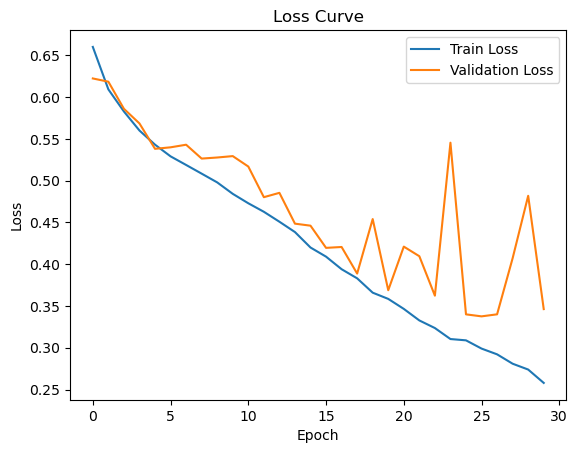

In [9]:
plt.figure()

plt.plot(
    df["epoch"],
    df["loss"],
    label="Train Loss"
)

plt.plot(
    df["epoch"],
    df["val_loss"],
    label="Validation Loss"
)

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.savefig("../assets/loss_curve.png")

plt.show()

Accuracy Curve

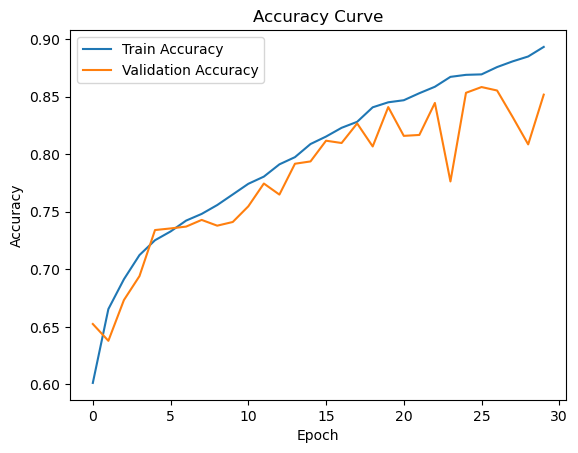

In [10]:
plt.figure()

plt.plot(
    df["epoch"],
    df["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    df["epoch"],
    df["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.savefig("../assets/accuracy_curve.png")

plt.show()

Load Best Model

In [11]:
MODEL_PATH = "../models/best_model.keras"

model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Model loaded.")

Model loaded.


Load Validation Dataset

In [12]:

VAL_DIR = "../data/cats_and_dogs/validation"

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    image_size=(160, 160),

    batch_size=32,

    shuffle=False,

    label_mode="binary"
)

# Normalize pixel values (VERY IMPORTANT)
val_ds = val_ds.map(
    lambda x, y: (x / 255.0, y)
)
sample_batch = next(iter(val_ds))

images, labels = sample_batch

print("Pixel min:", np.min(images.numpy()))
print("Pixel max:", np.max(images.numpy()))
print("Validation dataset loaded and normalized.")

Found 4998 files belonging to 2 classes.
Pixel min: 0.0
Pixel max: 1.0
Validation dataset loaded and normalized.


Generate Predictions

In [13]:

y_true = np.concatenate(
    [y for x, y in val_ds],
    axis=0
)

y_pred = np.concatenate(
    [model.predict(x) for x, y in val_ds],
    axis=0
)

# Convert probabilities to class labels
y_pred_class = (y_pred > 0.5).astype(int)

print("Predictions generated.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Confusion Matrix

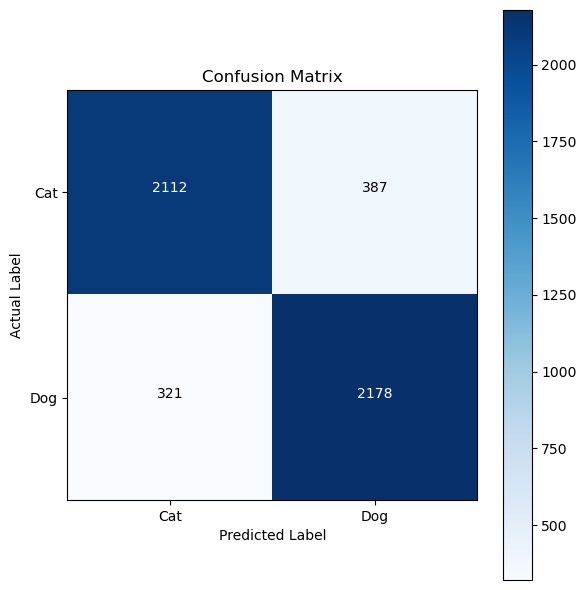

In [14]:

cm = confusion_matrix(
    y_true,
    y_pred_class
)

plt.figure(figsize=(6, 6))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap=plt.cm.Blues
)

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(2)

plt.xticks(
    tick_marks,
    ["Cat", "Dog"]
)

plt.yticks(
    tick_marks,
    ["Cat", "Dog"]
)

# Add numbers inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")

plt.tight_layout()

plt.savefig("../assets/confusion_matrix.png")

plt.show()

In [15]:
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2112  387]
 [ 321 2178]]


Classification Report

In [16]:

report = classification_report(
    y_true,
    y_pred_class,
    target_names=["Cat", "Dog"]
)

print(report)

with open(
        "../assets/classification_report.txt",
        "w"
) as f:
    f.write(report)

              precision    recall  f1-score   support

         Cat       0.87      0.85      0.86      2499
         Dog       0.85      0.87      0.86      2499

    accuracy                           0.86      4998
   macro avg       0.86      0.86      0.86      4998
weighted avg       0.86      0.86      0.86      4998



ROC Curve

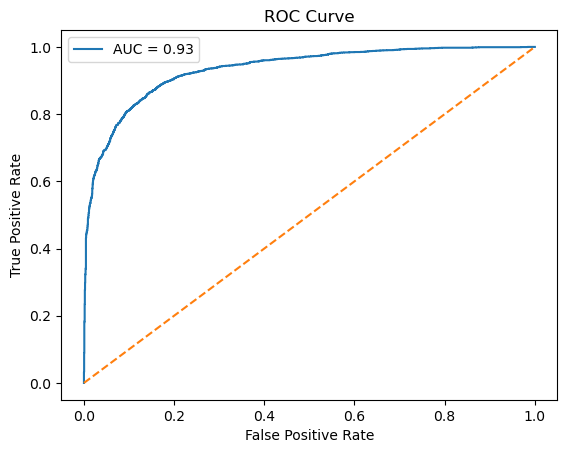

In [17]:

fpr, tpr, _ = roc_curve(
    y_true,
    y_pred
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure()

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.savefig("../assets/roc_curve.png")

plt.show()

Final Accuracy

In [18]:

from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(
    y_true,
    y_pred_class
)

print(
    f"Validation Accuracy: {test_accuracy:.4f}"
)

Validation Accuracy: 0.8583
